In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset
df = pd.read_csv('LoanData.csv')
print("Initial Dataset Shape:", df.shape)

# Handle missing values if any exist
df = df.dropna()

# 2. Identify Target and Features BEFORE encoding
# This prevents pandas from messing up the target column string
target_col = 'not_fully_paid' 

y = df[target_col]
X = df.drop(columns=[target_col])

# If 'index' is just a row identifier column, drop it from features so it doesn't skew results
if 'index' in X.columns:
    X = X.drop(columns=['index'])

# 3. Convert categorical text columns in features (like 'purpose') into numeric dummy variables
X = pd.get_dummies(X, drop_first=True)

# 4. Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Scale features (Crucial for the Perceptron model to converge!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing complete successfully!")
print(f"Train features shape: {X_train_scaled.shape}, Test features shape: {X_test_scaled.shape}")

Initial Dataset Shape: (100, 15)
Preprocessing complete successfully!
Train features shape: (80, 18), Test features shape: (20, 18)


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Ensemble Model
ensemble_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
ensemble_model.fit(X_train_scaled, y_train)

# Predict on testing data
ensemble_pred = ensemble_model.predict(X_test_scaled)

# Evaluation
print("=========================================")
print("        ENSEMBLE MODEL PERFORMANCE       ")
print("=========================================")
print(f"Accuracy: {accuracy_score(y_test, ensemble_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, ensemble_pred))

        ENSEMBLE MODEL PERFORMANCE       
Accuracy: 0.8500

Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92        17
           1       0.00      0.00      0.00         3

    accuracy                           0.85        20
   macro avg       0.42      0.50      0.46        20
weighted avg       0.72      0.85      0.78        20



c:\Users\myraa\OneDrive\Desktop\ML_LABS\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\myraa\OneDrive\Desktop\ML_LABS\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\myraa\OneDrive\Desktop\ML_LABS\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

In [5]:
from sklearn.linear_model import Perceptron

# Initialize the Perceptron Model
perceptron_model = Perceptron(max_iter=1000, tol=1e-3, random_state=42)

# Train the model
perceptron_model.fit(X_train_scaled, y_train)

# Predict on testing data
perceptron_pred = perceptron_model.predict(X_test_scaled)

# Evaluation
print("=========================================")
print("       PERCEPTRON MODEL PERFORMANCE      ")
print("=========================================")
print(f"Accuracy: {accuracy_score(y_test, perceptron_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, perceptron_pred))

       PERCEPTRON MODEL PERFORMANCE      
Accuracy: 0.7500

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.86        17
           1       0.00      0.00      0.00         3

    accuracy                           0.75        20
   macro avg       0.42      0.44      0.43        20
weighted avg       0.71      0.75      0.73        20



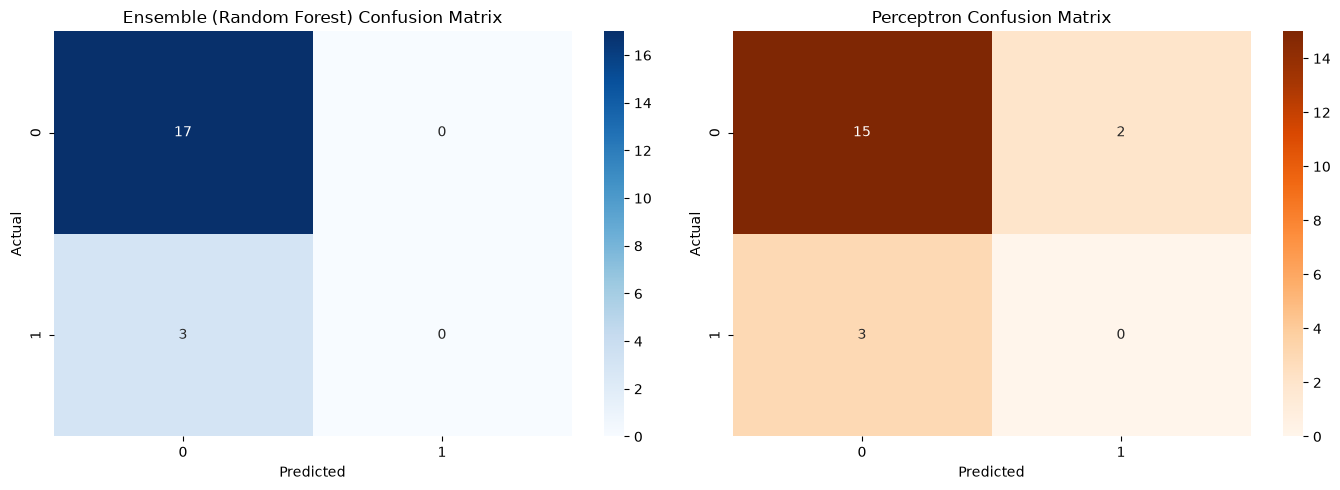

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Ensemble Confusion Matrix
sns.heatmap(confusion_matrix(y_test, ensemble_pred), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Ensemble (Random Forest) Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# Perceptron Confusion Matrix
sns.heatmap(confusion_matrix(y_test, perceptron_pred), annot=True, fmt='d', cmap='Oranges', ax=ax[1])
ax[1].set_title('Perceptron Confusion Matrix')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()